In [1]:
import pandas as pd
import wandb
api = wandb.Api()

# Project is specified by <entity/project-name>
runs = api.runs("niks_priv/sort_of_clevr")

summary_list, config_list, name_list = [], [], []
for run in runs:
    # .summary contains the output keys/values for metrics like accuracy.
    #  We call ._json_dict to omit large files
    summary_list.append(run.summary._json_dict)

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k,v in run.config.items()
          if not k.startswith('_')})

    # .name is the human-readable name of the run.
    name_list.append(run.name)

runs_df = pd.DataFrame({
    "summary": summary_list,
    "config": config_list,
    "name": name_list
    })

runs_df.to_csv("project.csv")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/nik/.netrc.


In [ ]:
%matplotlib inline

from pathlib import Path
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

SOC_NPZ = '/home/nik/workspace/ImperialWork/msc_project/SyncNetProject/data/sort_of_clevr-seed1-train36000-test1000-img75-obj5-q10-t-1/test.npz'
SQOOP_NPZ = '/home/nik/workspace/ImperialWork/msc_project/SyncNetProject/data/sqoop-rhs1/val_seen.npz'

OUT_DIR = Path('./outputs') / 'figures'
OUT_DIR.mkdir(exist_ok=True)

mpl.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 140,
    'savefig.dpi': 400,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.02,
})

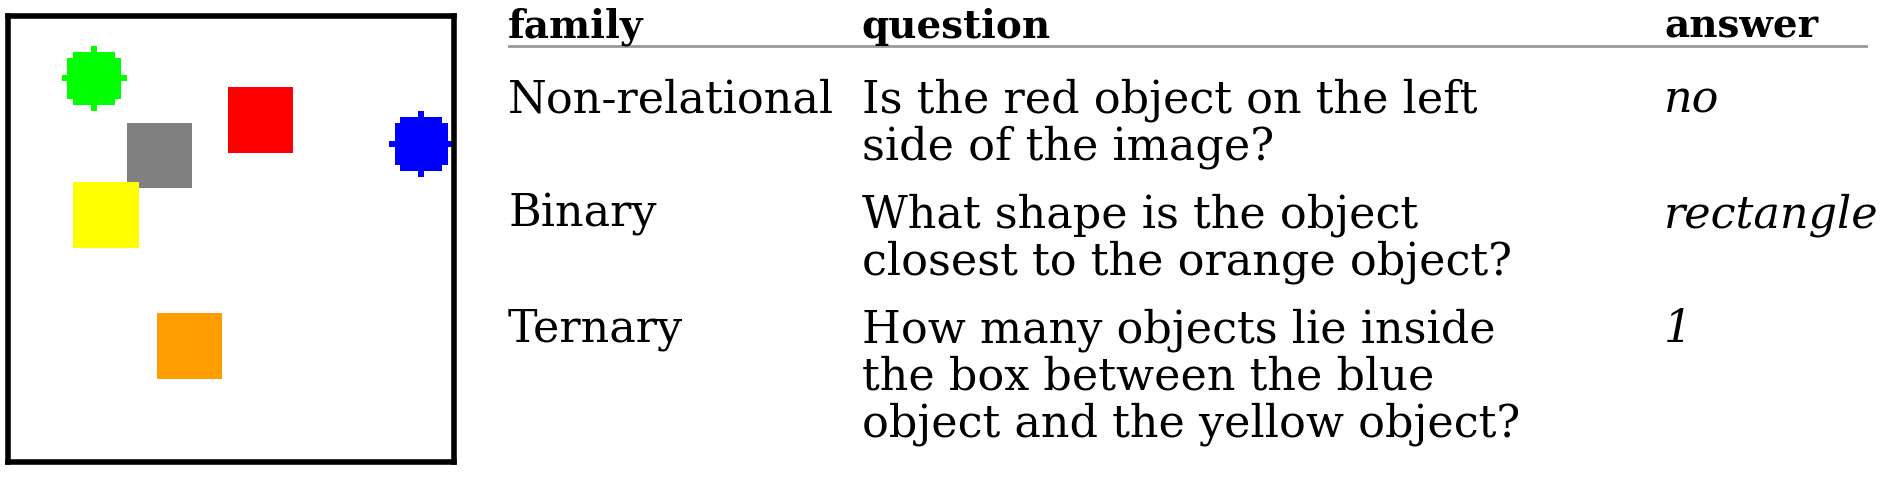

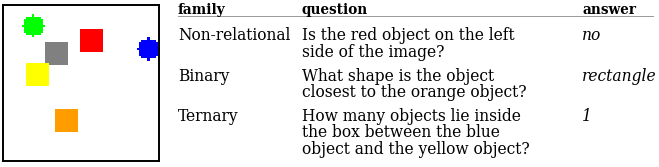

In [ ]:
import textwrap

from IPython.display import Image, display
from src.datasets.sort_of_clevr.translate import translate_question, translate_answer

soc = np.load(SOC_NPZ, allow_pickle=False)

scene = 0
chosen = [
    ('Non-relational', 'nonrel_questions', 'nonrel_answers', 0),
    ('Binary', 'binary_questions', 'binary_answers', 0),
    ('Ternary', 'ternary_questions', 'ternary_answers', 1),
]

q_left = 0.26
q_wrap = 30
a_left = 0.85
fontsize = 8.0

blocks = []
for label, qkey, akey, j in chosen:
    q = soc[qkey][scene][j]
    a = soc[akey][scene][j]
    blocks.append((label, textwrap.wrap(translate_question(q), q_wrap),
                   translate_answer(a, q)))

n_lines = sum(len(lines) for _, lines, _ in blocks)
line_height = 1.0 / (n_lines + 0.45 * len(blocks) + 1.5)

fig = plt.figure(figsize=(6.0, 1.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 3.05], wspace=0.06)

ax1 = fig.add_subplot(gs[0])
ax1.imshow(soc['images'][scene][..., ::-1], interpolation='nearest')
ax1.set_xticks([])
ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color('black')

ax2 = fig.add_subplot(gs[1])
ax2.axis('off')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)

y = 1.0
ax2.text(0.0, y, 'family', weight='bold', va='top', fontsize=7.0)
ax2.text(q_left, y, 'question', weight='bold', va='top', fontsize=7.0)
ax2.text(a_left, y, 'answer', weight='bold', va='top', fontsize=7.0)
y -= line_height
ax2.plot([0, 1], [y + 0.2 * line_height, y + 0.2 * line_height],
         color='#999999', linewidth=0.5)
y -= 0.5 * line_height

for label, lines, answer in blocks:
    ax2.text(0.0, y, label, va='top', fontsize=fontsize)
    ax2.text(a_left, y, answer, va='top', fontsize=fontsize, style='italic')
    for line in lines:
        ax2.text(q_left, y, line, va='top', fontsize=fontsize)
        y -= line_height
    y -= 0.45 * line_height

fig.savefig(OUT_DIR / 'soc_example.png')
display(Image(OUT_DIR / 'soc_example.png'))

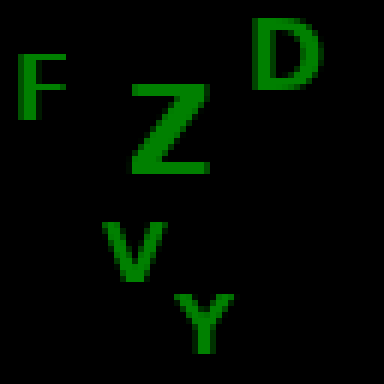

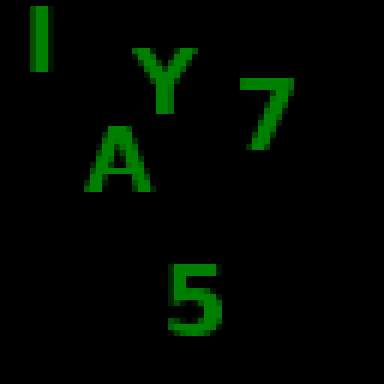

In [ ]:
d = np.load(SQOOP_NPZ, allow_pickle=False)

scale = 6

for i in range(2):
    img = np.repeat(np.repeat(d['images'][i], scale, axis=0), scale, axis=1)
    path = OUT_DIR / f'sqoop_example_{i}.png'
    plt.imsave(path, img)
    display(Image(path))